* DSC 550-T301 Data Mining
* Week 2 Exercise
* Peter Lozano

# 1. Introduction

This data was pulled from [UC ICS](https://archive.ics.uci.edu/dataset/911/recipe+reviews+and+user+feedback+dataset) and the dataset is called '**Recipe Reviews and User Feedback**'.

This dataset contains recipe reviews and user feedback, which can be used for various data mining and analysis tasks. It includes information such as user ratings in the form of number of stars (1-5), comments, and other feedback related to different recipes. What particularly intrigues me about this dataset is the potential to analyze user preferences, identify popular recipes, and gain insights into the factors that contribute to positive or negative feedback.

Understanding this will help culinary platforms optimize their recommendation engines and prioritize high-quality content.

# 2. Identify a question or question(s) that you would like to explore in your data set.

* What is the overall distribution of star ratings, and how prevalent are the unrated (0-star) reviews?
  - Missing ratings are denoted by 0 stars. This is how the dataset indicates that a user did not provide a rating for a particular recipe.
* Does a user's site reputation influence the likelihood of them giving a high or low star rating?
* Is there a correlation between the number of "thumps up" a comment receives and the number of replies it generates?
* Do lower-rated recipes attract more negative engagement (thumbs down) compared to highly-rated ones?

## Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter # For formatting axis tick labels
import seaborn as sns
import scipy # For correlation calculations

Alternatively, I could import the dataset using `from ucimlrepo import fetch_ucirepo` after installing the `ucimlrepo` package. This would void the necessity to download the CSV file manually. However, for this exercise, I will manually download the CSV file and load it using `pandas`.

# 3. Create at least three graphs that help answer these questions. Make sure your graphs are clearly readable and are labeled appropriately and professional. (4.) Explain what you have learned from each of your graphs.

## Load the dataset

In [2]:
df = pd.read_csv("Data/Recipe Reviews and User Feedback Dataset.csv",
                 index_col=0 # To use the first column as the index
)
df.head()

,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...


I can see how the data is structured. What I'm looking for is how the dataset handles the metrics I will use for analysis, such as how the thumbs up and thumbs downs are recorded, the user_id to help identify unique users, and how missing or zero values are represented. This will help me understand the reliability and completeness of the data for my analysis.

## Graph 1: Distribution of Star Ratings

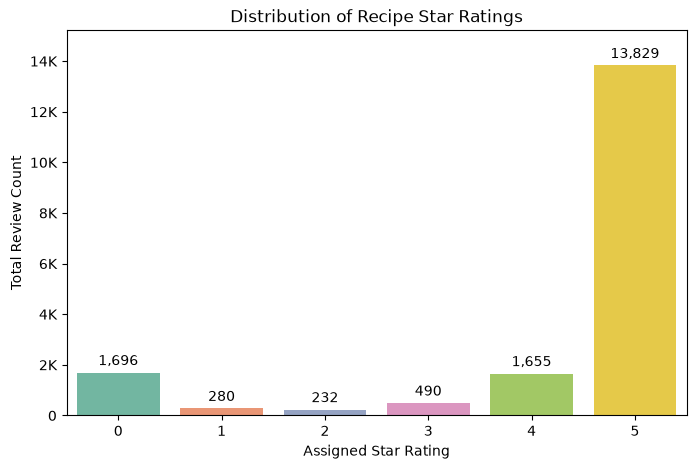

In [3]:
# Using countplot to visualize star rating distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df, 
    x='stars', # star rating on x-axis
    palette='Set2', # color palette for the bars
    hue='stars', # color by star rating
    legend=False # Removing legend
)

# Formatting the y-axis to display thousands with 'K' notation
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda y, _: # For every y-axis, tick mark:
            # Divide the y-value by 1000 and append 'K'
            f'{int(y/1000)}K'
                # If the y-value is greater than or = 1000
                if y >= 1000
                # Otherwise, just display the integer value
                else str(int(y))
    )
)

# Iterating through all bars (containers) ensures every single bar receives a data label
for container in ax.containers:
    ax.bar_label(
        container,
        # List comprehension to format each bar's value with a comma separator
        labels=[
            # Rule for v
            f'{int(v):,}'
            # Apply v to each datavalue passed in for loop
            for v in container.datavalues
        ],
        padding=3,
        label_type='edge'
    )

# Adding some extra space for bar labels at the top of the plot
ax.margins(y=0.10)

plt.title('Distribution of Recipe Star Ratings')
plt.xlabel('Assigned Star Rating')
plt.ylabel('Total Review Count')
plt.show()

I can immediately see a heavy skew towards higher star ratings in the distribution of this dataset. Most online reviews lean toward positive extremes or sit at 0.

## Graph 2: User Reputation by Star Rating

The dataset has a user reputation score for each user. However, I'm not familiar with whether this score changes over time for the same user.

I need to see if the 'user_reputation' is unique for each user. I will select a name at random to see the changes.

In [4]:
# Check the data rows are for the user 'u_7oJ0YWDuESeV' where the user reputation is unique
df[df['user_id'] == 'u_7oJ0YWDuESeV'].drop_duplicates(subset=['user_reputation'])

,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
14,4,17826,Amish Breakfast Casserole,sp_aUSaElGf_17826_c_22bLsG6xa4YzCgyYIilhMkfDaWt,u_7oJ0YWDuESeV,grandmascooking22,20,1640101544,0,17,1,5,827,I&#39;ve made this for several family gatherin...
16,6,21444,Favorite Chicken Potpie,sp_aUSaElGf_21444_c_1xuBoXvmWCNFcQai3mrAPRGRm0m,u_7oJ0YWDuESeV,grandmascooking22,1,1631195267,0,7,1,0,775,Made this per recipe but omitted the onions an...
4,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_26ZQONc92TJiGbq93W7zrAdOFXW,u_7oJ0YWDuESeV,grandmascooking22,90,1647628595,0,12,4,5,724,This is a nice tasting cauliflower soup. I re...
14,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_20vqzUva80kyFAudeYGtMAFMmmP,u_7oJ0YWDuESeV,grandmascooking22,10,1636935672,0,12,10,5,679,I made this recipe exactly as recipe said. I ...
4,15,10252,Li’l Cheddar Meat Loaves,sp_aUSaElGf_10252_c_23qUn2VmRdA1a1FwpYaPqIwu5H3,u_7oJ0YWDuESeV,grandmascooking22,50,1642461273,0,1,0,5,633,I liked the review of using jalapeno ketchup s...


Checking the individual records where the rating is unqiue for the user 'u_7oJ0YWDuESeV', I can see that the user's reputation does change over time. 
This indicates that the 'user_reputation' is not static and can vary for the same user across different records.

Let me see how this looks in a visualization.

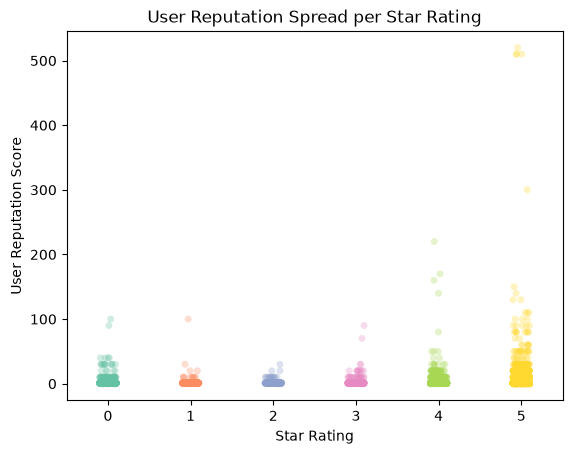

In [5]:
# A strip plot with jitter and transparency reveals the true density of individual data points
sns.stripplot(
    data=df, 
    x='stars', 
    y='user_reputation', # Setting the y-axis to user reputation
    palette='Set2', 
    hue='stars', 
    jitter=True, # Adding jitter to spread out the points
    legend=False, 
    alpha=0.3 # Adding transparency to the points
)

plt.title('User Reputation Spread per Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('User Reputation Score')
plt.show()

Using a strip plot with jitter and transparency, we can visualize the spread and density of individual data points for user reputation across the different star ratings. 

**What is this telling us?**

I'm observing how user reputation varies for each star rating because I know that an individual's reputation can change over time. The reputation score tells me that the individual reviewer has a certain level of credibility or exposure to the platform at the time of the review.

Splitting the reputation by the star rating allows me to see how these credible users tend to rate over time. I can identify a pattern that over time, users with higher reputation scores may exhibit higher rating behavior for the products or services they review. 

However, I'm not specifically stating that lower reputation users always give lower ratings; there is a clear cluster of lower reputation users who still provide high ratings, indicating that reputation is not the sole determinant of rating behavior.

## Graph 3: Thumbs Up vs. Reply Count

Next, I want to see the engagement of the program and how users interact with the content through thumbs up and replies. What I'm ultimately looking for here is if the reactions (thumbs up) correlate with the level of discussion (replies) generated by the content.

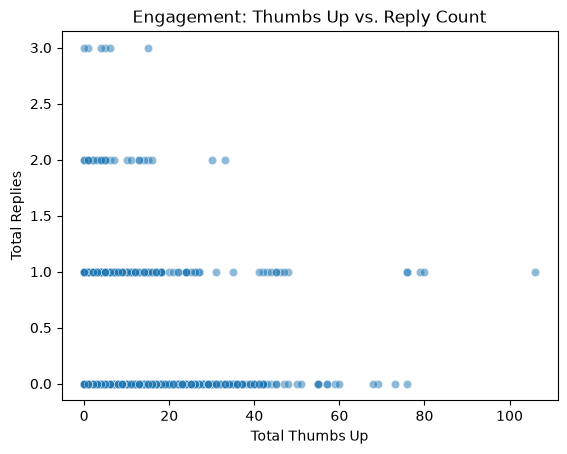

In [6]:
# Scatter plot using thumbs up and reply count
sns.scatterplot(
    data=df, 
    x='thumbs_up', 
    y='reply_count', 
    alpha=0.5 # Adding transparency to the points
)


plt.title('Engagement: Thumbs Up vs. Reply Count')
plt.xlabel('Total Thumbs Up')
plt.ylabel('Total Replies')
plt.show()

It appears that there isn't a strong correlation between thumbs up and reply count. To confirm what I already suspect to be true, I can calculate the Spearman correlation coefficient, which is more appropriate for skewed and discrete data.

In [7]:
# Using spearman because the data is highly skewed and discrete
correlation = df['thumbs_up'].corr(df['reply_count'], method='spearman')
print(correlation)

0.17743932128046017


The result of `0.177` indicates a weak positive correlation between thumbs up and reply count.

However, I haven't checked the thumbs down count yet, which could also provide insight into user engagement.

## Graph 4: Thumbs Down vs. Reply Count

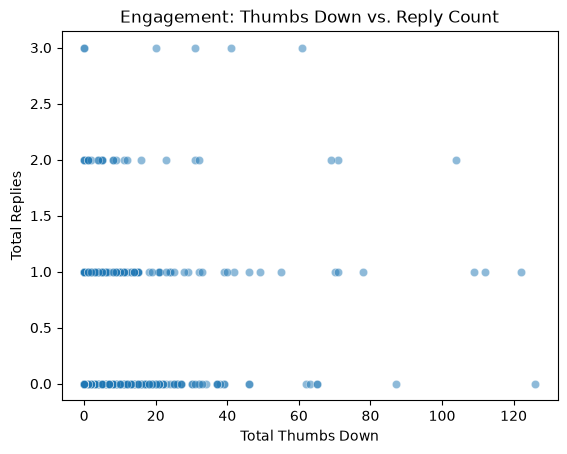

In [8]:
# Scatter plot using thumbs up and reply count
sns.scatterplot(
    data=df, 
    x='thumbs_down', 
    y='reply_count', 
    alpha=0.5 # Adding transparency to the points
)


plt.title('Engagement: Thumbs Down vs. Reply Count')
plt.xlabel('Total Thumbs Down')
plt.ylabel('Total Replies')
plt.show()

This appears to be much more evenly distributed compared to the thumbs up count, indicating that negative engagement is less skewed. There is a slight negative pattern between thumbs down and reply count. It shows that the more replies, the amount of thumbs down tends to decrease.

For confirmation, I can again calculate the correlation. I will still use the Spearman correlation coefficient since this dataset has heavy 0 values, which can affect the Pearson correlation.

In [9]:
# Calculate the Pearson correlation coefficient for thumbs down and reply count
correlation = df['thumbs_down'].corr(df['reply_count'], method='spearman')
print(correlation)

0.21925738100782344


Welp, I was wrong about the negative correlation being some what present. That is why we check the correlation coefficient! The 0 values in the dataset is something that can be easily overlooked when visually inspecting the scatter plot. Although the pattern is visually present, you would be mistaken because a majority of the data points are concentrated at 0, which skews the visual interpretation.

## Graph 5: Overall Reaction vs. Reply Count

Let me try combining both thumbs up and down to finally confirm once and for all that there is no correlation.

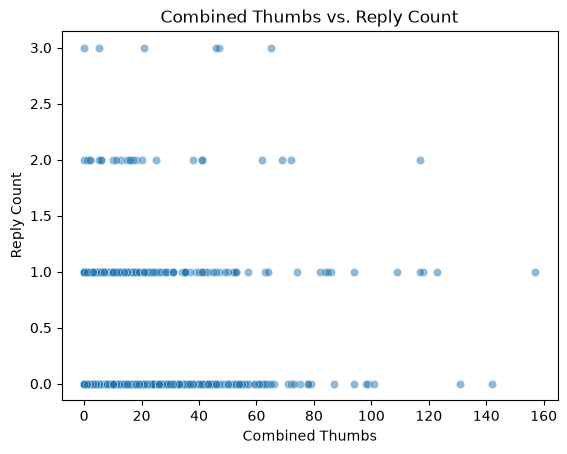

In [10]:
# Combined Thumbs Up and Down vs. Reply Count
df['combined_thumbs'] = df['thumbs_up'] + df['thumbs_down']

# Graph the combined_thumbs vs. Reply Count
sns.scatterplot(
    data=df,
    x='combined_thumbs',
    y='reply_count',
    alpha=0.5
)
plt.xlabel('Combined Thumbs')
plt.ylabel('Reply Count')
plt.title('Combined Thumbs vs. Reply Count')
plt.show()

In [11]:
correlation_combined = df['combined_thumbs'].corr(df['reply_count'],method='spearman')
print(correlation_combined)

0.19349061283401078


Based on the analysis, it is clear that both the thumbs up and down reactions do not exhibit a strong correlation with the reply count. This suggests that the reactions are largely independent of the number of replies a post receives.

# 5. Write a conclusion that summarizes your findings.

**Conclusion**

Based on my analysis of this dataset, I have found that the dataset is heavily skewed towards 5 star ratings and that null ratings have been defaulted to 0. 

Also, I have found that the platform captures user reputations at the time of each review, which provides context for understanding the influence of user reputation on the ratings they provide. With that information, it becomes easy to analyze how more time on this platform influences user behavior and rating patterns. I have noted that users with higher reputations tend to give more higher ratings consistently.

Lastly, I observed the correlation of reactions with the reply count and found that both thumbs up and thumbs down reactions do not exhibit a strong correlation with the reply count, suggesting that these reactions are largely independent of the number of replies a post receives.

Overall, the platform has a great system for capturing user behavior and feedback, which allows for a comprehensive analysis of user interactions, reputations, and the impact of these factors on the ratings. The reactions system on the other hand, appears to be less informative in understanding user engagement, as it does not strongly correlate with the number of replies a post receives.

This is not to say that there is something wrong with the reactions system; it simply indicates that it may not be as useful for analyzing user engagement (replies) as other metrics, like user reputation or the number of reviews a user has contributed.